In [1]:
import os
import pandas as pd
import re

In [2]:
header = ["execid", "benchmark", "instance", "executable", "cost", "status", "exit_code", "real", "time", "user", "system", "memory"]

result_dir = "results"
df = None
for file in os.listdir(result_dir):
    if not file.endswith(".tsv"):
        continue
    file = f"{result_dir}/{file}"
    df_curr = pd.read_csv(file, sep="\t", names=header, index_col=False)
    df = pd.concat([df, df_curr]) if not df is None else df_curr
 
df.insert(len(header), "win", False)
df.insert(len(header)+1, "score", 0)
df["cost"] = df["cost"].str.replace(",","").astype(float)
df["exit_code"] = df["exit_code"].astype(int)
df["O"] = df["exit_code"] == 30
df

,execid,benchmark,instance,executable,cost,status,exit_code,real,time,user,system,memory,win,score,O
0,nomin,GraphColouring,0001-graph_colouring-125-0_1200.asp,clingo-plainmaximize-amo,2076.0,outof time,11,"1,200.56","1,200.29","1,200.02",0.27,142.80,False,0,False
1,nomin,GraphColouring,0001-graph_colouring-125-0_2400.asp,clingo-plainmaximize-amo,2076.0,outof time,11,"1,200.45","1,200.37","1,200.16",0.21,119.70,False,0,False
2,nomin,GraphColouring,0001-graph_colouring-125-0_3600.asp,clingo-plainmaximize-amo,2076.0,outof time,11,"1,200.49","1,200.14","1,199.80",0.34,119.50,False,0,False
3,nomin,GraphColouring,0001-graph_colouring-125-0_4800.asp,clingo-plainmaximize-amo,2076.0,outof time,11,"1,200.25","1,200.14","1,199.29",0.85,118.70,False,0,False
4,nomin,GraphColouring,0001-graph_colouring-125-0_6000.asp,clingo-plainmaximize-amo,2076.0,outof time,11,"1,201.14","1,200.95","1,200.62",0.33,119.50,False,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,nomin,TSP,095-490-tsp.asp,clingo-amomaximize-amo-nomin,26599.0,outof time,29,"1,205.49","1,201.04","1,179.25",21.79,"3,060.90",False,0,False
1296,nomin,TSP,096-495-tsp.asp,clingo-amomaximize-amo-nomin,26421.0,outof time,29,"1,206.32","1,200.95","1,173.00",27.95,"3,242.80",False,0,False
1297,nomin,TSP,097-500-tsp.asp,clingo-amomaximize-amo-nomin,25988.0,outof time,10,"1,207.60","1,201.07","1,179.29",21.78,"3,091.30",False,0,False
1298,nomin,TSP,098-505-tsp.asp,clingo-amomaximize-amo-nomin,26987.0,outof time,29,"1,207.51","1,201.08","1,175.63",25.45,"3,163.60",False,0,False


In [3]:
df[df["benchmark"] == "K"]["instance"].values

array([], dtype=object)

In [4]:
from typing import Dict, List


def _filterDF(df: pd.DataFrame, filterList: List[Dict[str, str]] = {}, positive=True):
    for filter in filterList:
        sliceDf = None
        regexStr = ""
        for column in filter:
            regex = filter[column]
            notStr = "~" if not positive else ""
            regexStr = f" and {notStr}{regex}" if regexStr else regex
            sliceDf = (df[column].str.contains(regex)) if sliceDf is None else sliceDf & (df[column].str.contains(regex))
        print(f"{'Keeping' if positive else 'Removing'} {regexStr} from {column}")
        if positive:
            df = df[sliceDf]
        else:
            df = df[~sliceDf]

    return df


def filterDF(df: pd.DataFrame, positiveFilter: List[Dict[str, str]] = {}, negativeFilter: List[Dict[str, str]] = {}):
    df = _filterDF(df, positiveFilter, True)
    df = _filterDF(df, negativeFilter, False)
    return df


positiveFilter = [
]

negativeFilter = [
{
    "benchmark": r"Knapsack$",
}
]

df = filterDF(df, positiveFilter, negativeFilter)

Removing Knapsack$ from benchmark


In [5]:
df["benchmark"] = df["benchmark"].str.replace("KnapsackAmomaximize", "K")
df["benchmark"] = df["benchmark"].str.replace("GraphColouring", "GC")
# df["executable"] = df["executable"].str.replace("clingo-plainmaximize-amo", "\\textsc{{clingo}}")
# df["executable"] = df["executable"].str.replace("clingo-amomaximize-amo-nomin", "\\textsc{{amomaximize}}")
df["executable"] = df["executable"].str.replace("clingo-plainmaximize-amo", "clingo")
df["executable"] = df["executable"].str.replace("clingo-amomaximize-amo-nomin", "amomaximize")

/var/folders/60/msx2m7995xv41v59mx28gt5w0000gn/T/ipykernel_1674/4177483135.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["benchmark"] = df["benchmark"].str.replace("KnapsackAmomaximize", "K")
/var/folders/60/msx2m7995xv41v59mx28gt5w

In [6]:
# Win
groubByInstance = df.groupby("instance")

for instance, groupedDf in groubByInstance:
    max_cost = groupedDf["cost"].max()
    instance_mask = (df["instance"] == instance)
    df.loc[instance_mask & (df["cost"] == max_cost), "win"] = True
    df.loc[instance_mask, "score"] = df[instance_mask]["cost"]/max_cost

/var/folders/60/msx2m7995xv41v59mx28gt5w0000gn/T/ipykernel_1674/4193054492.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.         0.99962089]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[instance_mask, "score"] = df[instance_mask]["cost"]/max_cost


In [7]:
df_wod = df.copy()
df_wod = df_wod[df_wod["benchmark"] == "WOD"]
df_wod.insert(0,"p","0.2")
df_wod.loc[df_wod["instance"].str.contains(r"cp0_7\.asp$"),"p"]= "0.7"
df_wod.loc[df_wod["instance"].str.contains(r"cp0_5\.asp$"),"p"]= "0.5"

pivot_wod = df_wod.pivot_table(index=["p"],columns=["executable"], values=["win","O", "score"], aggfunc={"win":"sum", "O": "sum", "score": "mean"}, margins=True, margins_name='Total', fill_value=-1)
pivot_wod = pivot_wod.reorder_levels([1,0], axis=1).sort_index(axis=1)
pivot_wod = pivot_wod.drop(columns="Total", level=0)

for col in pivot_wod.columns[(pivot_wod.columns.get_level_values(1) == "O") | (pivot_wod.columns.get_level_values(1) == "win")]:
    pivot_wod.loc[:, col].astype(int)

for col in pivot_wod.columns[(pivot_wod.columns.get_level_values(1) == "score")]:
    pivot_wod.loc[:, col] = pivot_wod.loc[:, col].round(2)

pivot_wod

/opt/homebrew/anaconda3/envs/amosum/lib/python3.14/site-packages/pandas/core/reshape/pivot.py:332: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  margin_dummy[cols] = margin_dummy[cols].apply(
/opt/homebrew/anaconda3/envs/amosum/lib/python3.1

executable amomaximize             clingo            
                     O score   win      O score   win
p                                                    
0.2                3.0  0.70  15.0    0.0  0.93  22.0
0.5                3.0  0.63  14.0    0.0  0.96  29.0
0.7                0.0  0.76  24.0    0.0  1.00  41.0
Total              6.0  0.70  53.0    0.0  0.97  92.0

In [8]:
df_wod

,p,execid,benchmark,instance,executable,cost,status,exit_code,real,time,user,system,memory,win,score,O
600,0.7,nomin,WOD,001-wod-u182-t110-s10-cp0_7.asp,clingo,919.0,outof memory,11,206.98,198.30,188.65,9.65,"8,230.30",True,1.000000,False
601,0.2,nomin,WOD,002-wod-u126-t68-s10-cp0_2.asp,clingo,5237.0,outof time,11,"1,201.39","1,200.57","1,197.54",3.03,"2,046.20",False,0.522446,False
602,0.7,nomin,WOD,003-wod-u188-t139-s10-cp0_7.asp,clingo,622.0,outof memory,11,332.58,323.64,313.27,10.37,"8,217.20",True,1.000000,False
603,0.5,nomin,WOD,004-wod-u176-t162-s10-cp0_5.asp,clingo,-1.0,outof memory,1,242.65,232.32,217.17,15.15,"8,193.80",True,1.000000,False
604,0.2,nomin,WOD,005-wod-u431-t439-s10-cp0_2.asp,clingo,-1.0,outof memory,1,170.65,164.87,155.73,9.14,"8,199.00",True,1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0.2,nomin,WOD,096-wod-u369-t355-s10-cp0_2.asp,amomaximize,-1.0,outof memory,143,645.11,625.47,602.24,23.23,"8,206.20",True,1.000000,False
1196,0.2,nomin,WOD,097-wod-u372-t341-s10-cp0_2.asp,amomaximize,477.0,outof memory,29,295.55,282.50,273.47,9.03,"8,230.10",False,0.251185,False
1197,0.5,nomin,WOD,098-wod-u153-t89-s10-cp0_5.asp,amomaximize,997.0,outof memory,29,259.89,247.68,241.28,6.40,"8,198.50",False,0.510235,False
1198,0.7,nomin,WOD,099-wod-u176-t202-s10-cp0_7.asp,amomaximize,-1.0,outof memory,143,697.60,677.83,654.53,23.30,"8,194.70",True,1.000000,False


In [9]:
# pivot = df.pivot_table(index=["executable"],columns=["benchmark"], values=["win","O", "score"], aggfunc={"win":"sum", "O": "sum", "score": "mean"}, margins=True, margins_name='Total', fill_value=-1)
pivot = df.pivot_table(index=["benchmark"],columns=["executable"], values=["win","O", "score"], aggfunc={"win":"sum", "O": "sum", "score": "mean"}, margins=True, margins_name='Total', fill_value=-1)
# pivot = pivot[:-1]
pivot = pivot.reorder_levels([1,0], axis=1).sort_index(axis=1)
pivot = pivot.drop(columns="Total", level=0)
pivot = pivot.rename(columns={
    'clingo-amomaximize-amo-nomin': 'amomaximize',
    'clingo-plainmaximize-amo': 'clingo'
}, level=0)
pivot.columns.names = [None, None]


/opt/homebrew/anaconda3/envs/amosum/lib/python3.14/site-packages/pandas/core/frame.py:4343: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self[k1] = value[k2]
/opt/homebrew/anaconda3/envs/amosum/lib/python3.14/site-packages/pandas/core/resha

In [10]:
for col in pivot.columns[(pivot.columns.get_level_values(1) == "O") | (pivot.columns.get_level_values(1) == "win")]:
    pivot.loc[:, col].astype(int)

for col in pivot.columns[(pivot.columns.get_level_values(1) == "score")]:
    pivot.loc[:, col] = pivot.loc[:, col].round(2)

In [11]:
pivot

amomaximize              clingo             
                    O score    win      O score    win
benchmark                                             
GC                0.0  1.00  289.0    0.0  0.88   11.0
K                 0.0  0.91   21.0    0.0  1.00   79.0
TSP               5.0  0.99   82.0    2.0  0.94   20.0
WOD               6.0  0.70   53.0    0.0  0.97   92.0
Total            11.0  0.93  445.0    2.0  0.93  202.0

In [12]:
def get_pivot_latex(pivot: pd.DataFrame):
    pivot_latex = pivot.copy().astype(object)
    metrics = set(m for _, m in pivot_latex.columns)

    for m in metrics:
        metric_cols = [c for c in pivot_latex.columns if c[1] == m]
        
        for i in range(len(pivot_latex)):
            vals = pivot_latex.loc[pivot_latex.index[i], metric_cols]
            maxVal = vals.max()
            
            for col in metric_cols:
                v = pivot_latex.at[pivot_latex.index[i], col] 
                pivot_latex.at[pivot_latex.index[i], col] = (
                    rf"\textbf{{{v}}}" if v == maxVal and v != 0 else str(v)
                )

    pivot_latex = pivot_latex.rename(columns={
        'clingo': '\\textsc{{clingo}}',
        'amomaximize': '\\textsc{{amomaximize}}',
    }, level=0)
    return pivot_latex

pivot_latex = get_pivot_latex(pivot)
pivot_latex

\textsc{{amomaximize}}                                 \
                               O          score             win   
benchmark                                                         
GC                           0.0   \textbf{1.0}  \textbf{289.0}   
K                            0.0           0.91            21.0   
TSP                 \textbf{5.0}  \textbf{0.99}   \textbf{82.0}   
WOD                 \textbf{6.0}            0.7            53.0   
Total              \textbf{11.0}  \textbf{0.93}  \textbf{445.0}   

          \textsc{{clingo}}                                
                          O          score            win  
benchmark                                                  
GC                      0.0           0.88           11.0  
K                       0.0   \textbf{1.0}  \textbf{79.0}  
TSP                     2.0           0.94           20.0  
WOD                     0.0  \textbf{0.97}  \textbf{92.0}  
Total                   2.0  \textbf{0.93}          202.0

In [13]:

latex = pivot_latex.to_latex(
    multicolumn=True,           
    multicolumn_format='c',     
    multirow=True,              
    bold_rows=False,
    float_format="%.2f",        
    na_rep='-',                 
    label="tab:results",
    position="t",
    escape=False,               
    # index=False
)
print(latex)

\begin{table}[t]
\label{tab:results}
\begin{tabular}{lllllll}
\toprule
 & \multicolumn{3}{c}{\textsc{{amomaximize}}} & \multicolumn{3}{c}{\textsc{{clingo}}} \\
 & O & score & win & O & score & win \\
benchmark &  &  &  &  &  &  \\
\midrule
GC & 0.0 & \textbf{1.0} & \textbf{289.0} & 0.0 & 0.88 & 11.0 \\
K & 0.0 & 0.91 & 21.0 & 0.0 & \textbf{1.0} & \textbf{79.0} \\
TSP & \textbf{5.0} & \textbf{0.99} & \textbf{82.0} & 2.0 & 0.94 & 20.0 \\
WOD & \textbf{6.0} & 0.7 & 53.0 & 0.0 & \textbf{0.97} & \textbf{92.0} \\
Total & \textbf{11.0} & \textbf{0.93} & \textbf{445.0} & 2.0 & \textbf{0.93} & 202.0 \\
\bottomrule
\end{tabular}
\end{table}



In [14]:
pivot_latex_wod = get_pivot_latex(pivot_wod)
pivot_latex_wod

executable \textsc{{amomaximize}}             \textsc{{clingo}}  \
                                O score   win                 O   
p                                                                 
0.2                  \textbf{3.0}   0.7  15.0               0.0   
0.5                  \textbf{3.0}  0.63  14.0               0.0   
0.7                           0.0  0.76  24.0               0.0   
Total                \textbf{6.0}   0.7  53.0               0.0   

executable                                
                    score            win  
p                                         
0.2         \textbf{0.93}  \textbf{22.0}  
0.5         \textbf{0.96}  \textbf{29.0}  
0.7          \textbf{1.0}  \textbf{41.0}  
Total       \textbf{0.97}  \textbf{92.0}

In [15]:
import subprocess
from pathlib import Path
import shutil

def create_latex_visualization(latex_input: str, output_dir: str, output_name, tex_name: str):
    latex = rf"""
            \documentclass{{article}}
            \usepackage{{booktabs}}
            \usepackage{{multirow}}
            \pagestyle{{empty}}
            \begin{{document}}
            {latex_input}
            \end{{document}}
            """
    output_path = Path(f"{output_dir}/{output_name}")
    output_path.mkdir(parents=True, exist_ok=True)
    tex_name = f"{tex_name}.tex"
    tex_file = output_path / tex_name
    tex_file.write_text(latex)
    subprocess.run(
        ["/Library/TeX/texbin/pdflatex", tex_name],
        cwd=output_path
    )

In [16]:
create_latex_visualization(latex, "tables", "nominres", "table")

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./table.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/booktabs/booktabs.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/multirow/multirow.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/l3backend/l3backend-pdftex.def)
(./table.aux)
[1{/usr/local/texlive/2025/texmf-var/fonts/map/pdftex/updmap/pdftex.map}]
(./table.aux) )</usr/local/texlive/2025/texmf-dist/fonts/type1/public/amsfonts/
cm/cmbx10.pfb></usr/local/texlive/2025/texmf-dist/fonts/type1/public/amsfonts/c
m/cmcsc10.pfb></usr/local/texlive/2025/texmf-dist/fonts/type1/public/amsfonts/c
m/cmr10.pfb>
Output written on 

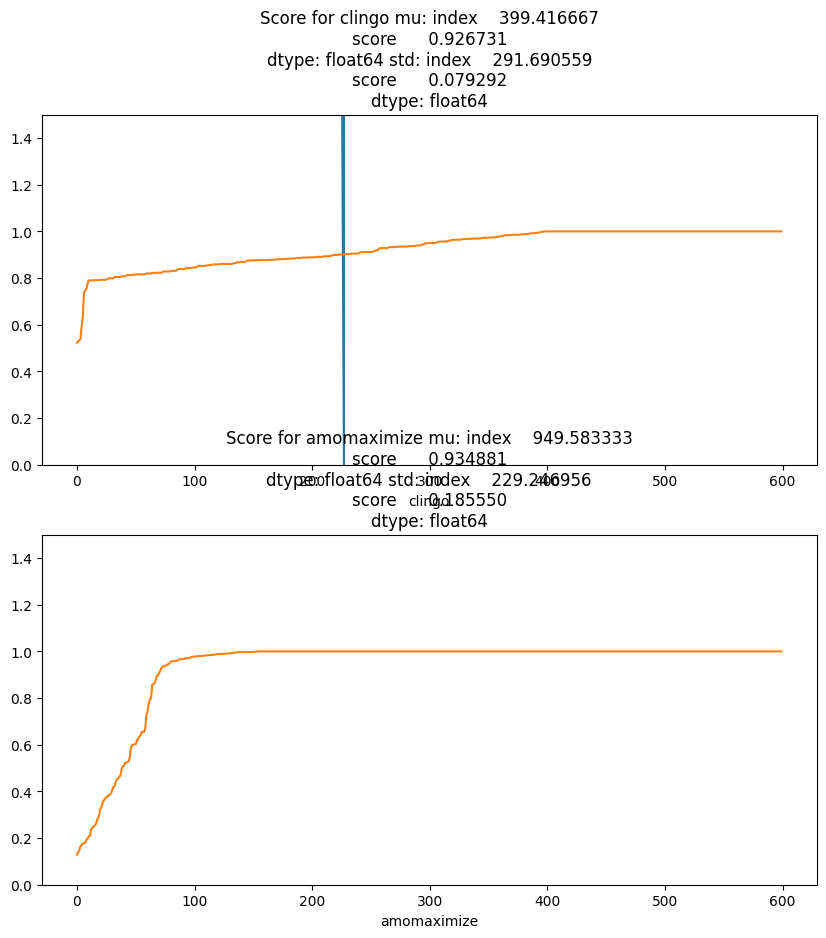

In [31]:
import matplotlib.pyplot as plt

solvers = df["executable"].unique()
n = len(solvers)
fig, axes = plt.subplots(n,figsize=(10, n * 5))

for i in range(len(solvers)):
    solver = solvers[i]
    ax = axes[i]
    scores = df[df["executable"] == solver]["score"].sort_values().reset_index()
    mean = scores.mean()
    std = scores.std()
    ax.plot(scores)
    ax.set_title(f"Score for {solver} mu: {mean} std: {std}")
    ax.set_ylim(ymin=0, ymax=1.5) 
    ax.set_xlabel(solver)


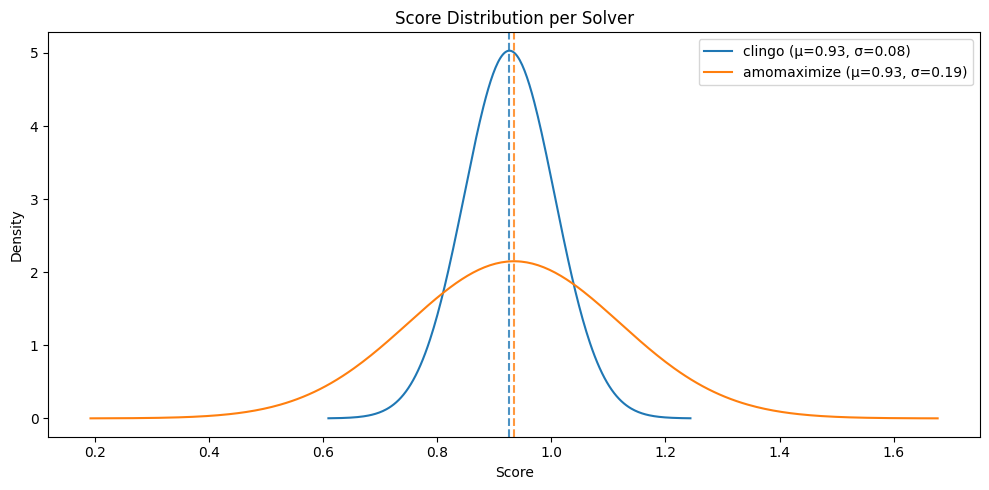

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, solver in enumerate(df["executable"].unique()):
    scores = df[df["executable"] == solver]["score"]
    mean = scores.mean()
    std = scores.std()
    color = colors[i % len(colors)]

    x = np.linspace(mean - 4*std, mean + 4*std, 300)
    ax.plot(x, norm.pdf(x, mean, std), color=color, label=f"{solver} (μ={mean:.2f}, σ={std:.2f})")
    ax.axvline(mean, linestyle="--", color=color, alpha=0.8)

ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.set_title("Score Distribution per Solver")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
def generate_pgfplots_latex(df, executable_col="executable", score_col="score"):
    colors = ["blue", "red", "green!60!black", "orange", "purple", "teal"]
    solvers = df[executable_col].unique()

    plots = []
    for i, solver in enumerate(solvers):
        scores = df[df[executable_col] == solver][score_col]
        mean = scores.mean()
        std = scores.std()
        color = colors[i % len(colors)]
        domain_min = mean - 4 * std
        domain_max = mean + 4 * std
        peak = 1 / (std * (2 * 3.14159) ** 0.5)

        plots.append(rf"""
                    % {solver}
                    \addplot[{color}, thick, domain={0}:{1.05}, samples=200] {{gauss({mean:.4f}, {std:.4f})}};
                    \addlegendentry{{{solver} ($\mu={mean:.4f}$, $\sigma={std:.4f}$)}}
                    \draw[{color}, dashed] (axis cs:{mean:.4f}, 0) -- (axis cs:{mean:.4f}, {peak:.4f});""")

        plots_str = "\n".join(plots)

        latex = rf"""
    \begin{{figure}}
        \centering
        \begin{{tikzpicture}}
        \pgfmathdeclarefunction{{gauss}}{{2}}{{%
        \pgfmathparse{{1/(#2*sqrt(2*pi))*exp(-((x-#1)^2)/(2*#2^2))}}%
        }}
        \begin{{axis}}[
            width=12cm, height=6cm,
            xlabel={{Score}},
            ylabel={{Density}},
            title={{Cumulative Density Score}},
            legend style={{at={{(0.1,0.9)}}, anchor=north west}},
            grid=major,
        ]
        {plots_str}
        \end{{axis}}
        \end{{tikzpicture}}
        \caption{{TODO}}
        \label{{fig:cumulative:score}}
    \end{{figure}}
        """
    return latex

In [20]:
print(generate_pgfplots_latex(df))


    \begin{figure}
        \centering
        \begin{tikzpicture}
        \pgfmathdeclarefunction{gauss}{2}{%
        \pgfmathparse{1/(#2*sqrt(2*pi))*exp(-((x-#1)^2)/(2*#2^2))}%
        }
        \begin{axis}[
            width=12cm, height=6cm,
            xlabel={Score},
            ylabel={Density},
            title={Cumulative Density Score},
            legend style={at={(0.1,0.9)}, anchor=north west},
            grid=major,
        ]
        
                    % clingo
                    \addplot[blue, thick, domain=0:1.05, samples=200] {gauss(0.9267, 0.0793)};
                    \addlegendentry{clingo ($\mu=0.9267$, $\sigma=0.0793$)}
                    \draw[blue, dashed] (axis cs:0.9267, 0) -- (axis cs:0.9267, 5.0313);

                    % amomaximize
                    \addplot[red, thick, domain=0:1.05, samples=200] {gauss(0.9349, 0.1855)};
                    \addlegendentry{amomaximize ($\mu=0.9349$, $\sigma=0.1855$)}
                    \draw[red, dashed] (axis 

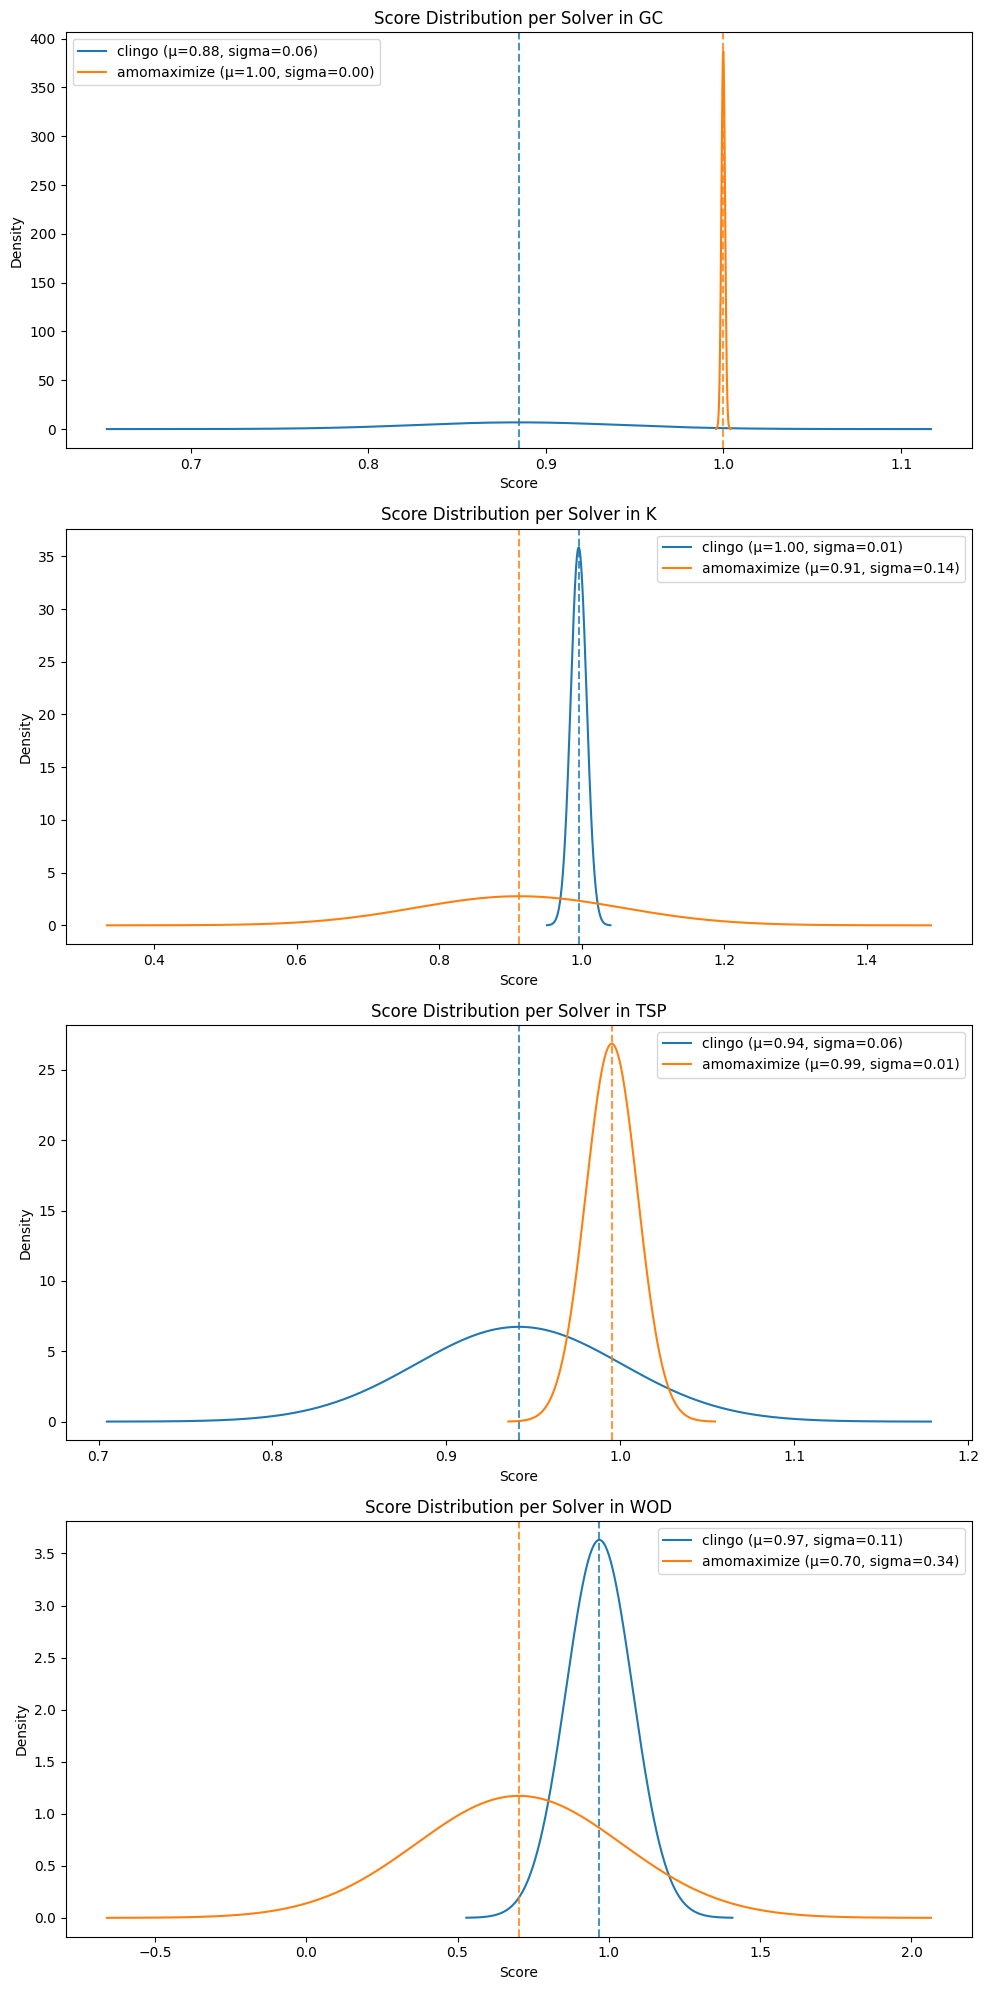

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


groupByBench = df.groupby("benchmark")
n = len(groupByBench)
# fig, axes = plt.subplots(n//2,2, figsize=(10, 5*n))
fig, axes = plt.subplots(n,1, figsize=(10, 5*n))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

idBench = 0
for bench, dfBench in groupByBench:
    # ax = axes[idBench//2][idBench%2]
    ax = axes[idBench]
    for i, solver in enumerate(df["executable"].unique()):
        scores = dfBench[dfBench["executable"] == solver]["score"]
        mean = scores.mean()
        std = scores.std()
        color = colors[i % len(colors)]
        x = np.linspace(mean - 4*std, mean + 4*std, 300)
        ax.plot(x, norm.pdf(x, mean, std), color=color, label=f"{solver} (μ={mean:.2f}, sigma={std:.2f})")
        ax.axvline(mean, linestyle="--", color=color, alpha=0.8)

    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_title(f"Score Distribution per Solver in {bench}")
    ax.legend()
    idBench+=1
plt.tight_layout()
plt.show()

In [22]:
def generate_pgfplots_latex_grid(df, executable_col="executable", score_col="score", bench_col="benchmark"):
    colors = ["blue", "red", "green!60!black", "orange", "purple", "teal"]
    solvers = df[executable_col].unique()
    benchmarks = df[bench_col].unique()

    subfigures = []
    for idx, bench in enumerate(benchmarks):
        dfBench = df[df[bench_col] == bench]

        plots = []
        for i, solver in enumerate(solvers):
            scores = dfBench[dfBench[executable_col] == solver][score_col]
            mean = scores.mean().round(4)
            std = scores.std().round(4)
            color = colors[i % len(colors)]
            domain_min = mean - 4 * std
            domain_max = mean + 4 * std
            peak = 1 / (std * (2 * 3.14159) ** 0.5)

            plots.append(rf"""
\addplot[{color}, thick, domain={0:.2f}:{1.01:.2f}, samples=200] {{gauss({mean:.4f}, {std:.4f})}};
\addlegendentry{{{solver.replace('amomaximize','amomax')} (${mean:.2f}$, ${std:.2f}$)}}
\draw[{color}, dashed] (axis cs:{mean:.4f}, 0) -- (axis cs:{mean:.4f}, {peak:.4f});""")

        plots_str = "\n".join(plots)

        # after every 2 subfigures, add a newline for the grid
        end = "\n\\\\[1em]" if (idx + 1) % 2 == 0 else "%"

        subfigures.append(rf"""
\begin{{subfigure}}{{0.48\textwidth}}
\begin{{tikzpicture}}
\begin{{axis}}[
    width=6cm, height=4cm,
    xlabel={{Score}},
    ylabel={{Density}},
    title={{{bench}}},
    legend style={{at={{(0,1)}}, anchor=north west}},
    grid=major,
    title style={{font=\small}},
    tick label style={{font=\tiny}},
    label style={{font=\small}},
    legend style={{font=\tiny, at={{(0,1.01)}}, anchor=north west}},
]
{plots_str}
\end{{axis}}
\end{{tikzpicture}}
\end{{subfigure}}\hfill{end}""")
        
        subfigures_str = "\n".join(subfigures)

    latex = rf"""
\begin{{figure}}[t]
\centering
{subfigures_str}
\caption{{Score Distribution per Solver and Benchmark}}
\end{{figure}}
"""
    return latex

In [23]:
print(generate_pgfplots_latex_grid(df, executable_col="executable", score_col="score", bench_col="benchmark"))


\begin{figure}[t]
\centering

\begin{subfigure}{0.48\textwidth}
\begin{tikzpicture}
\begin{axis}[
    width=6cm, height=4cm,
    xlabel={Score},
    ylabel={Density},
    title={GC},
    legend style={at={(0,1)}, anchor=north west},
    grid=major,
    title style={font=\small},
    tick label style={font=\tiny},
    label style={font=\small},
    legend style={font=\tiny, at={(0,1.01)}, anchor=north west},
]

\addplot[blue, thick, domain=0.00:1.01, samples=200] {gauss(0.8847, 0.0580)};
\addlegendentry{clingo ($0.88$, $0.06$)}
\draw[blue, dashed] (axis cs:0.8847, 0) -- (axis cs:0.8847, 6.8783);

\addplot[red, thick, domain=0.00:1.01, samples=200] {gauss(0.9999, 0.0010)};
\addlegendentry{amomax ($1.00$, $0.00$)}
\draw[red, dashed] (axis cs:0.9999, 0) -- (axis cs:0.9999, 398.9424);
\end{axis}
\end{tikzpicture}
\end{subfigure}\hfill%

\begin{subfigure}{0.48\textwidth}
\begin{tikzpicture}
\begin{axis}[
    width=6cm, height=4cm,
    xlabel={Score},
    ylabel={Density},
    title={K},
   

In [24]:
import math
def generate_pgfplots_latex_grid_minipage(df, executable_col="executable", score_col="score", bench_col="benchmark"):
    colors = ["blue", "red", "green!60!black", "orange", "purple", "teal"]
    solvers = df[executable_col].unique()
    benchmarks = df[bench_col].unique()

    minipages = []
    for idx, bench in enumerate(benchmarks):
        dfBench = df[df[bench_col] == bench]

        plots = []
        for i, solver in enumerate(solvers):
            scores = dfBench[dfBench[executable_col] == solver][score_col]
            mean = scores.mean()
            std = scores.std()
            rounded_std = max(0.01, scores.std().round(2))
            color = colors[i % len(colors)]
            domain_min = mean - 4 * std
            domain_max = mean + 4 * std
            peak = 1 / (rounded_std * math.sqrt(2 * math.pi))
            # print(f"std: {std} solver{solver} bench: {bench}")
# \addlegendentry{{{solver} ($\mu={mean:.2f}$, $\sigma={std:.2f}$)}}
            plots.append(rf"""
\addplot[{color}, thick, domain={0}:{1:.2f}, samples=200] {{gauss({mean:.2f}, {rounded_std})}};
\addlegendentry{{\textsc{{{solver}}} ($\mu={mean:.2f}$, $\sigma={std:.2f}$)}}
\draw[{color}, dashed] (axis cs:{mean:.4f}, 0) -- (axis cs:{mean:.4f}, {peak:.2f});""")

        plots_str = "\n".join(plots)

        # after every 2 subfigures, add a newline for the grid
        # end = "\n\\\\[1em]" if (idx + 1) % 2 == 0 else "%"
        end = "\n\\hfill\n" if idx % 2 == 0 else ""
        # end = ""

        minipages.append(rf"""
\begin{{minipage}}{{0.45\textwidth}}
    \centering
    \begin{{tikzpicture}}
    \pgfmathdeclarefunction{{gauss}}{{2}}{{%
        \pgfmathparse{{1/(#2*sqrt(2*pi))*exp(-((x-#1)^2)/(2*#2^2))}}%
    }}
        \begin{{axis}}[
            width=8cm, height=5cm,
            xlabel={{Score}},
            ylabel={{Density}},
            title={{{bench}}},
            grid=major,
            title style={{font=\small}},
            tick label style={{font=\tiny}},
            label style={{font=\small}},
            legend style={{font=\scriptsize, at={{(0,1)}}, anchor=north west}},
        ]
        {plots_str}
        \end{{axis}}
    \end{{tikzpicture}}
\end{{minipage}}{end}""")
        
        minipages_str = "\n".join(minipages)

    latex = rf"""
\begin{{figure}}[t]
\centering
{minipages_str}
\caption{{Score Distribution per Solver and Benchmark}}
\end{{figure}}
"""
    return latex

In [25]:
print(generate_pgfplots_latex_grid_minipage(df, executable_col="executable", score_col="score", bench_col="benchmark"))


\begin{figure}[t]
\centering

\begin{minipage}{0.45\textwidth}
    \centering
    \begin{tikzpicture}
    \pgfmathdeclarefunction{gauss}{2}{%
        \pgfmathparse{1/(#2*sqrt(2*pi))*exp(-((x-#1)^2)/(2*#2^2))}%
    }
        \begin{axis}[
            width=8cm, height=5cm,
            xlabel={Score},
            ylabel={Density},
            title={GC},
            grid=major,
            title style={font=\small},
            tick label style={font=\tiny},
            label style={font=\small},
            legend style={font=\scriptsize, at={(0,1)}, anchor=north west},
        ]
        
\addplot[blue, thick, domain=0:1.00, samples=200] {gauss(0.88, 0.06)};
\addlegendentry{\textsc{clingo} ($\mu=0.88$, $\sigma=0.06$)}
\draw[blue, dashed] (axis cs:0.8847, 0) -- (axis cs:0.8847, 6.65);

\addplot[red, thick, domain=0:1.00, samples=200] {gauss(1.00, 0.01)};
\addlegendentry{\textsc{amomaximize} ($\mu=1.00$, $\sigma=0.00$)}
\draw[red, dashed] (axis cs:0.9999, 0) -- (axis cs:0.9999, 39.89);
 

In [26]:
1 / (0.01 * math.sqrt(2 * math.pi))

39.894228040143275